In [16]:
import sys
from pathlib import Path

parent = Path.cwd().parent
sys.path.append(str(parent))

In [17]:
from src.integrator import ComplexIntegrator
from src.integrand_builder import ContextManager, spherical
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

In [18]:
cm = ContextManager(force_rebuild = True) 

Compiling evaluator: "combined_result"
Done!


In [19]:
import symbolica


def get_integrals(masses, n_epochs, spe):
    unsub_res = []
    sub_res = []
    
    rng = symbolica.RandomNumberGenerator(0, 0)
    
    for m in tqdm(masses):
        cm.masses = list(m)

        ci3 = ComplexIntegrator(3)
        cm.a = 1
        cm.b = 0
        cm.c = 0
        unsub_int = ci3.integrate(cm.eval, spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        ci2 = ComplexIntegrator(3)
        cm.a = 1
        cm.b = 1
        cm.c = 1
        sub_int = ci2.integrate(cm.eval, spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        unsub_res.append(unsub_int)
        sub_res.append(sub_int)
    return unsub_res, sub_res

def get_reference(masses):
    baseline = []
    for m in masses:
        cm.masses = list(m)
        baseline.append(cm.get_reference())
    return baseline


In [20]:
def plot_convergence(xs, unsub_res, sub_res):
    plt.scatter(xs, [r.convergence() for r in unsub_res], label = 'without counterterm')
    plt.scatter(xs, [r.convergence() for r in sub_res], label = 'with counterterm')

    plt.ylabel('convergence')
    plt.legend()

In [21]:
def plot_real_result(xs, unsub_res, sub_res, reference_xs, reference):
    plt.plot(reference_xs, [r.real for r in reference], label = 'OneLOop')
    plt.scatter(xs, [r.real_avg for r in unsub_res], label = 'without counterterm')
    plt.scatter(xs, [r.real_avg for r in sub_res], label = 'with counterterm')
    plt.legend()

def plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference):
    plt.plot(reference_xs, [r.imag for r in reference], label = 'OneLOop')
    plt.scatter(xs, [r.imag_avg for r in unsub_res], label = 'without counterterm')
    plt.scatter(xs, [r.imag_avg for r in sub_res], label = 'with counterterm')
    plt.legend()

In [22]:
masses = (0.5-1j*0.75**np.linspace(3,23,20))[:,None] * np.ones(3)[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=100, spe = 100)
ref_masses = (0.5-1j*0.75**np.linspace(3,23,200))[:,None] * np.ones(3)[None,:]
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:10<00:00,  1.95it/s]


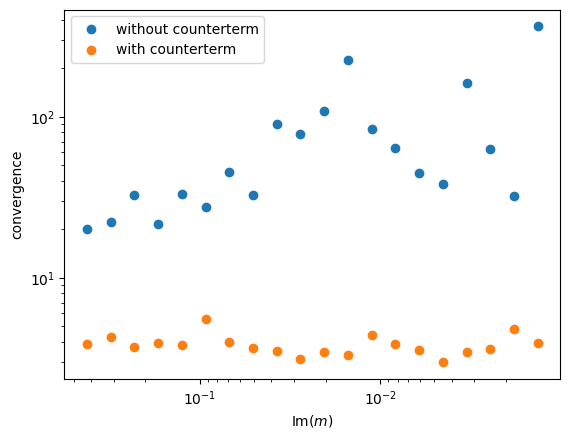

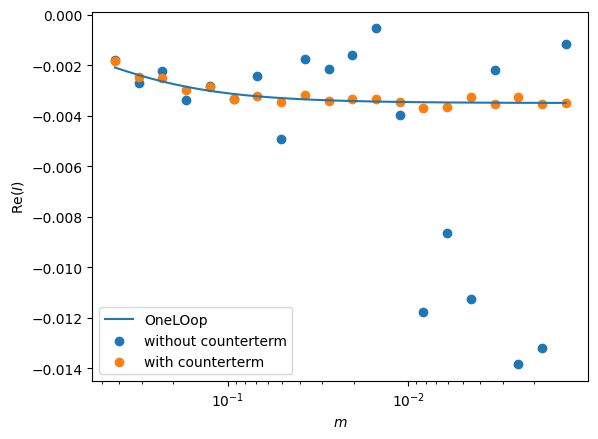

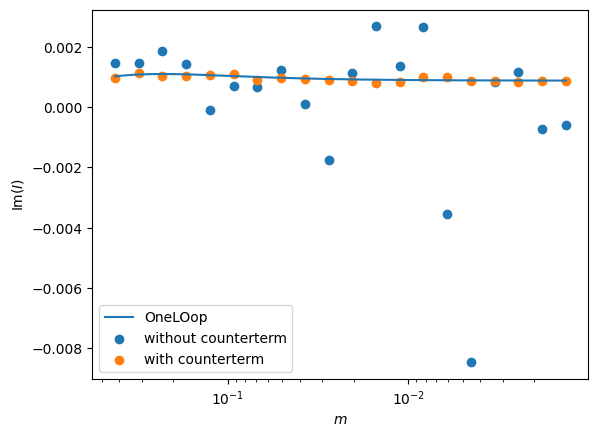

In [23]:
xs = -masses[:,0].imag
reference_xs = -ref_masses[:,0].imag
plt.show()
plot_convergence(xs, unsub_res, sub_res)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Im($m$)')
plt.gca().invert_xaxis()
plt.show()

plot_real_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xscale('log')
plt.xlabel('$m$')
plt.ylabel('Re($I$)')
plt.gca().invert_xaxis()
plt.show()

plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xscale('log')
plt.xlabel('$m$')
plt.ylabel('Im($I$)')
plt.gca().invert_xaxis()
plt.show()

In [24]:
masses = np.linspace(3.499**0.5,3.501**0.5,20)[:,None]* np.ones(3)[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=100, spe = 500)
ref_masses = np.linspace(3.499**0.5,3.501**0.5,200)[:,None]* np.ones(3)[None,:]
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:48<00:00,  2.41s/it]


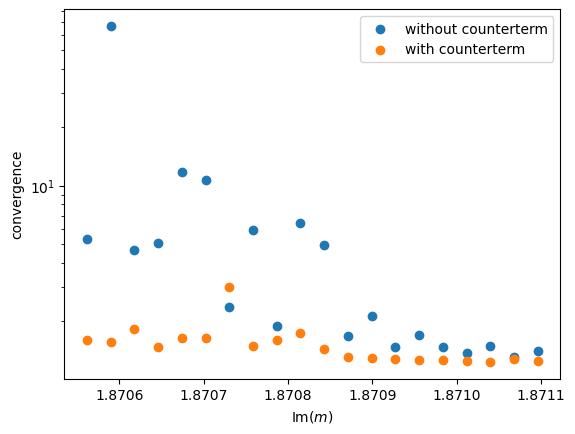

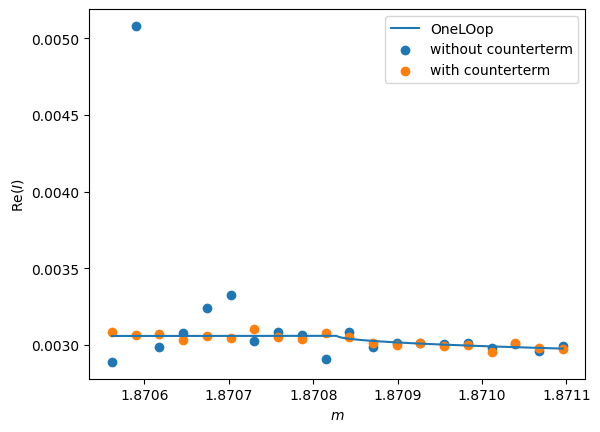

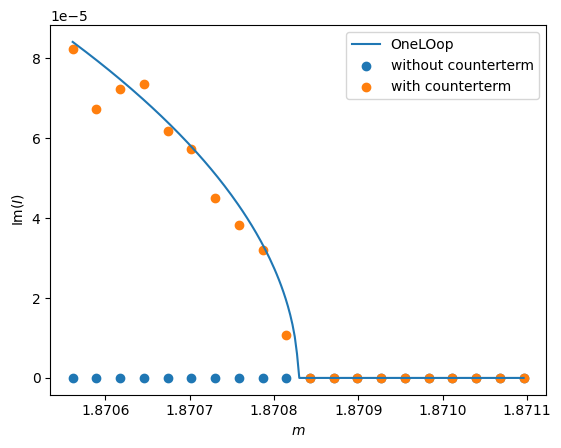

In [25]:
xs = masses[:,0]
reference_xs = ref_masses[:,0]
plt.show()
plot_convergence(xs, unsub_res, sub_res)
plt.yscale('log')
plt.xlabel('Im($m$)')
plt.show()

plot_real_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('$m$')
plt.ylabel('Re($I$)')
plt.show()

plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('$m$')
plt.ylabel('Im($I$)')
plt.show()

# set the center such that the origin is not inside the origin

In [26]:
cm.origin = np.array([0,2,0,0])
cm.get_threshold_report()

q = [-1.  -0.5  0.   0. ]
q² = 0.75
E-surface value at origin = 2.8603513883531875
q = [-1.   0.  -0.5  0. ]
q² = 0.75
E-surface value at origin = 3.6544427965902777
q = [-2.  -0.5 -0.5  0. ]
q² = 3.5
E-surface value at origin = 1.0372034736909352


In [35]:
masses = np.linspace(0.4,2.1,20)[:,None]* np.ones(3)[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=100, spe = 500)
ref_masses = np.linspace(0.4,2.1,200)[:,None]* np.ones(3)[None,:]
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:41<00:00,  2.09s/it]


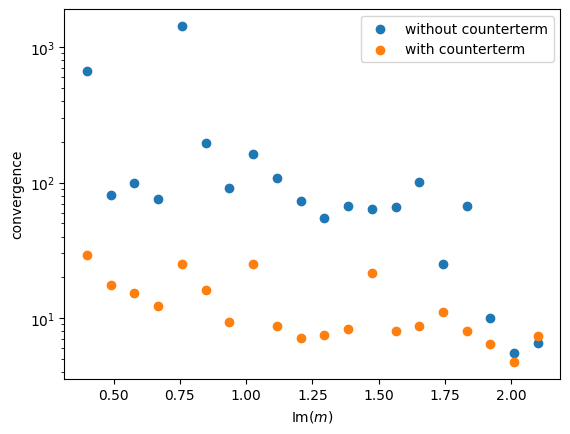

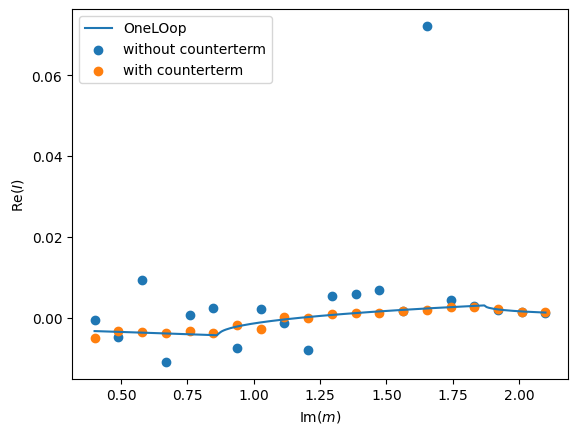

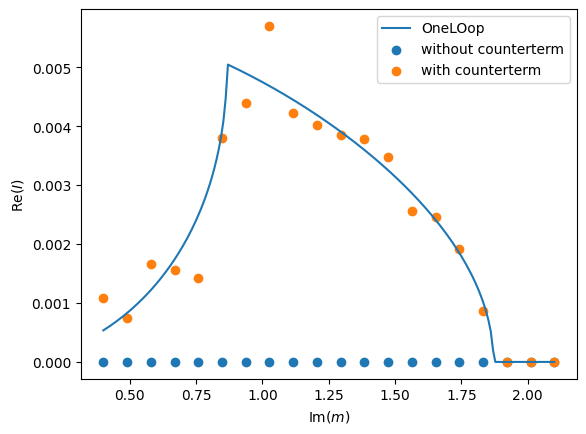

In [28]:
xs = masses[:,0]
reference_xs = ref_masses[:,0]
plt.show()
plot_convergence(xs, unsub_res, sub_res)
plt.yscale('log')
plt.xlabel('Im($m$)')
plt.show()

plot_real_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()

plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()

In [37]:
masses = np.linspace(0.4,2.1,20)[:,None]* np.array([1,1.2,0.8])[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=50, spe = 1000)
ref_masses = np.linspace(0.4,2.1,200)[:,None]* np.array([1,1.2,0.8])[None,:]
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:45<00:00,  2.25s/it]


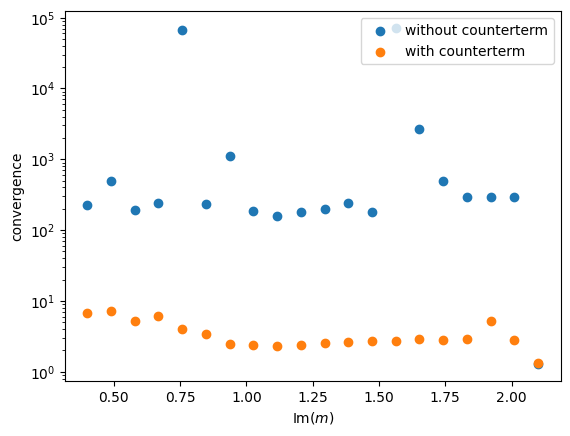

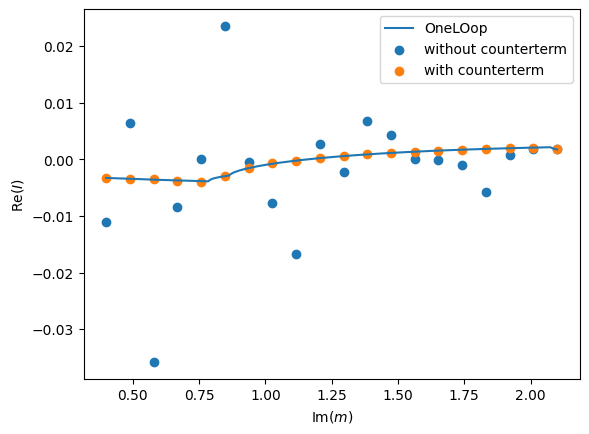

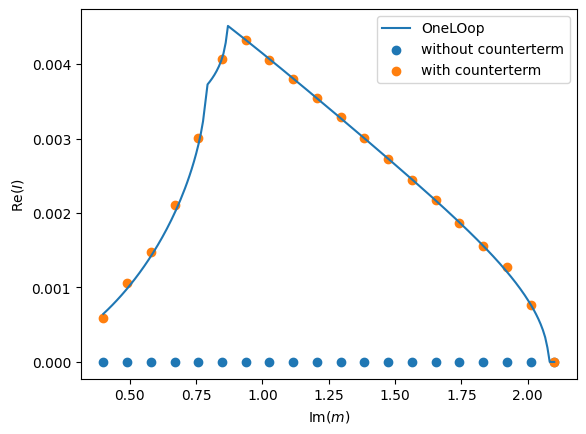

In [38]:
xs = masses[:,0]
reference_xs = ref_masses[:,0]
plt.show()
plot_convergence(xs, unsub_res, sub_res)
plt.yscale('log')
plt.xlabel('Im($m$)')
plt.show()

plot_real_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()

plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()